# Programming Assignment 1: Data Preparation and Understanding

**Image dataset:** Animal_Classification (https://www.kaggle.com/datasets/ayushv322/animal-classification)

**Four classes:** Buffalo, Elephant, Rhino, Zebra

**Text dataset:** student_8 tweet dataset (training set only, 3,000 records)

In [14]:
from pathlib import Path

DATA = Path.cwd() / "Animal_Classification"
CLASSES = ["Buffalo", "Elephant", "Rhino", "Zebra"]
N_PER_CLASS = 200  # used later for PCA; each folder has ~1000 images

def all_images(animal):
    """Return sorted file paths of every .jpg in that animal folder."""
    return sorted((DATA / animal).glob("*.jpg"))

def class_images(animal):
    """Return the first N_PER_CLASS file paths from that folder."""
    return all_images(animal)[:N_PER_CLASS]

for animal in CLASSES:
    total = len(all_images(animal))
    used = min(N_PER_CLASS, total)
    print(f"{animal}: using {used} of {total} images")

Buffalo: using 200 of 1000 images
Elephant: using 200 of 1000 images
Rhino: using 200 of 1000 images
Zebra: using 200 of 1000 images


## 2. Feature extraction: edge histogram and similarity measurements

Helper Methods:

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, exposure

def load_gray(path):
    img = io.imread(path)
    return color.rgb2gray(img)

def angle(dx, dy):
    """Calculate the angles between horizontal and vertical operators."""
    return np.mod(np.arctan2(dy, dx), np.pi)

def edge_hist(gray):
    angle_sobel = angle(filters.sobel_h(gray), filters.sobel_v(gray))
    hist, _ = exposure.histogram(angle_sobel, nbins=36)
    return hist

### 2(a) and 2(e) One image per class, plotted with its edge histogram

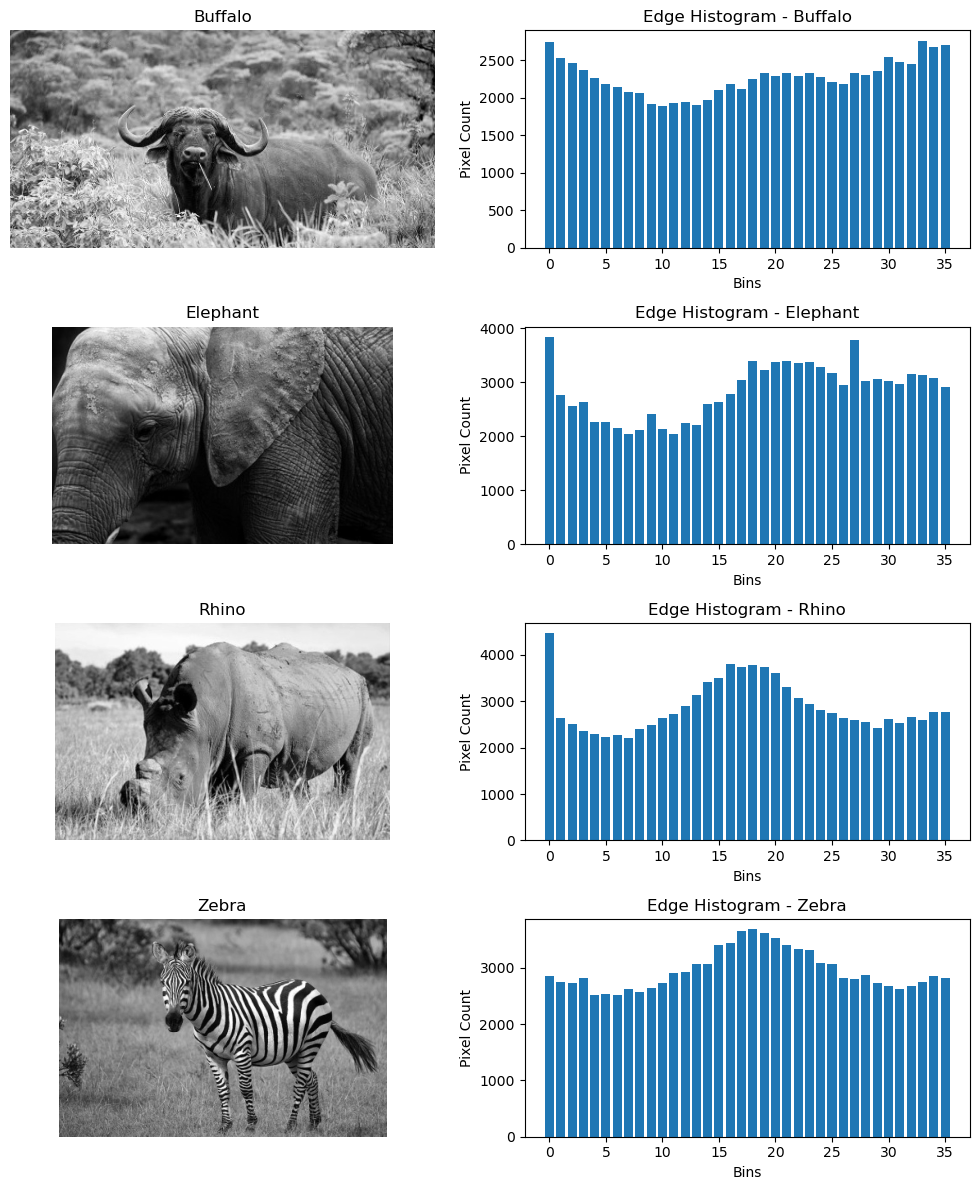

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(10, 12))
#print(axes);
hists = {}

for i, animal in enumerate(CLASSES):
    path = class_images(animal)[0]   # first image of this class (part 2a)
    gray = load_gray(path) #greyscalling the first loaded
    hist = edge_hist(gray)
    hists[animal] = hist

    ax_img, ax_hist = axes[i]

    ax_img.imshow(gray, cmap="gray")
    ax_img.set_title(animal)
    ax_img.axis("off")

    ax_hist.bar(range(36), hist)
    ax_hist.set_xlabel("Bins")
    ax_hist.set_ylabel("Pixel Count")
    ax_hist.set_title(f"Edge Histogram - {animal}")

plt.tight_layout()
plt.show()

### 2(f) Comparing two edge histograms

The Buffalo and Elephant histograms from above are compared with the three required measures.

In [17]:
from sklearn.metrics import pairwise

# Each histogram is 1 sample x 36 bins.
a = hists["Buffalo"].reshape(1, -1)
b = hists["Elephant"].reshape(1, -1)

# Each call returns a 1x1 matrix; [0, 0] is the single distance.
print("Euclidean distance:", pairwise.euclidean_distances(a, b)[0, 0].round(2))
print("Manhattan distance:", pairwise.manhattan_distances(a, b)[0, 0].round(2))
print("Cosine distance:   ", pairwise.cosine_distances(a, b)[0, 0].round(4))

Euclidean distance: 4144.06
Manhattan distance: 20464.0
Cosine distance:    0.0091


Euclidean and Manhattan distance is large because these histograms are raw pixel counts. A bigger photo just has more pixels, so the bars are taller and the two vectors look far apart even if the shape of the bars is similar.
Cosine is almost 0, which means the two histograms have almost the same mix of edge directions.

## 3. Histogram of Oriented Gradients (HOG)

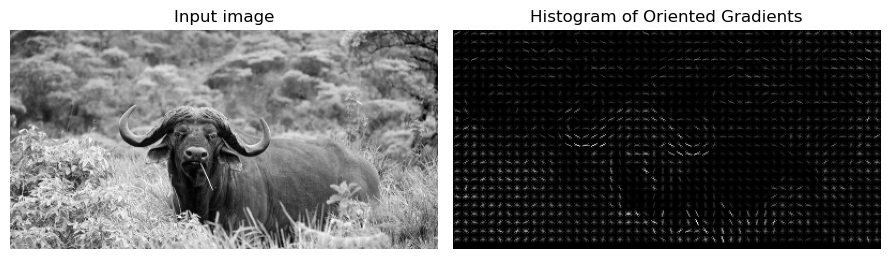

HOG descriptor length: 89424


In [18]:
from skimage.feature import hog

path = class_images("Buffalo")[0]
gray = load_gray(path)
fd, hog_image = hog(gray, visualize=True) #  keeping the defaults

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax1.imshow(gray, cmap="gray")
ax1.set_title("Input image")
ax1.axis("off")

ax2.imshow(exposure.rescale_intensity(hog_image), cmap="gray")  # HOG drawing is faint; brighten so the edge lines show
ax2.set_title("Histogram of Oriented Gradients")
ax2.axis("off")

plt.tight_layout()
plt.show()

print("HOG descriptor length:", len(fd))

## 4. Dimensionality reduction with PCA

### Helper: plot_2d method

One scatter-plot function for both PCA sections (images here, tweets later). Each section passes its own color dictionary.

In [19]:
def plot_2d(points, labels, title, colors):
    """Scatter 2D points using the color dict for this problem."""
    plt.figure(figsize=(9, 7))
    for name in np.unique(labels):
        class_points = points[labels == name]   # rows for this class only
        x = class_points[:, 0]                  # PC1
        y = class_points[:, 1]                  # PC2
        plt.scatter(x, y, c=colors[name], label=name, s=16, alpha=0.7)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.title(title)
    plt.show()

### 4(b), 4(c), 4(d)

In [20]:
# 4(b) turn each image into a 36-bin edge histogram
from sklearn.decomposition import PCA
histograms = []
labels = []
# storing histogram of animal images and their associated labels
for animal in CLASSES:
    for path in class_images(animal):
        gray = load_gray(path)
        histograms.append(edge_hist(gray))
        labels.append(animal)

X = np.array(histograms)   # shape: (n_images, 36)
labels = np.array(labels)
print("Histogram data shape:", X.shape)


Histogram data shape: (800, 36)


In [21]:
# 4(c) PCA uses only X, not the labels
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)  # 36 dimensions -> 2

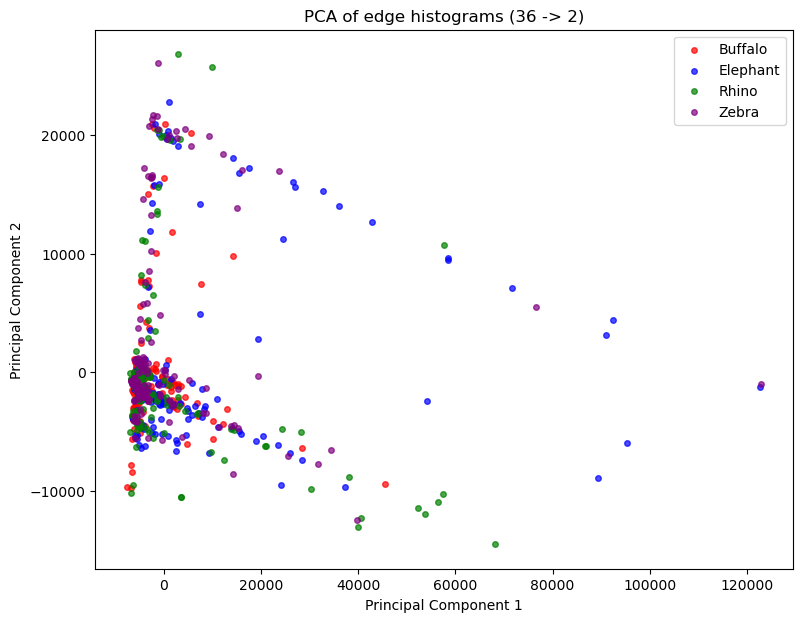

In [22]:
# 4(d) labels are used only to color the plot, the default colors were not the best at discriminating
animal_colors = {
    "Buffalo": "red",
    "Elephant": "blue",
    "Rhino": "green",
    "Zebra": "purple",
}
plot_2d(X2, labels, "PCA of edge histograms (36 -> 2)", animal_colors)

### Answer 4(d): how many classes are visually separable?

For this dataset I do not see separate clusters like the example. All four classes overlap, with a few scattered outliers. The outliers are mixed colors too, so no class is non-overlapping.

## Text processing: tweet dataset

**Text dataset:** student_8 tweet dataset

In [23]:
import json

train_path = Path.cwd() / "student_8" / "train.json"
rows = []
with train_path.open(encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))
tweets = [row["Tweet"] for row in rows]

print("Training records:", len(tweets))
print("Example:", tweets[0])

Training records: 3000
Example: i animated a little thing i might post it tomorrow since itll be a Good Thursday.. nice...


In [24]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

count_features = CountVectorizer().fit_transform(tweets)
tfidf_features = TfidfVectorizer().fit_transform(tweets)

n_tweets, n_features = count_features.shape
print("Token counts:", n_tweets, "tweets,", n_features, "features")
print("TF-IDF:      ", tfidf_features.shape[0], "tweets,", tfidf_features.shape[1], "features")
print("Dimensionality (both):", n_features)

Token counts: 3000 tweets, 9583 features
TF-IDF:       3000 tweets, 9583 features
Dimensionality (both): 9583


#### Dimensionality (both): 9583

Four classes: anger, love, sadness, surprise
('anger', 704)
('love', 280)
('sadness', 445)
('surprise', 87)


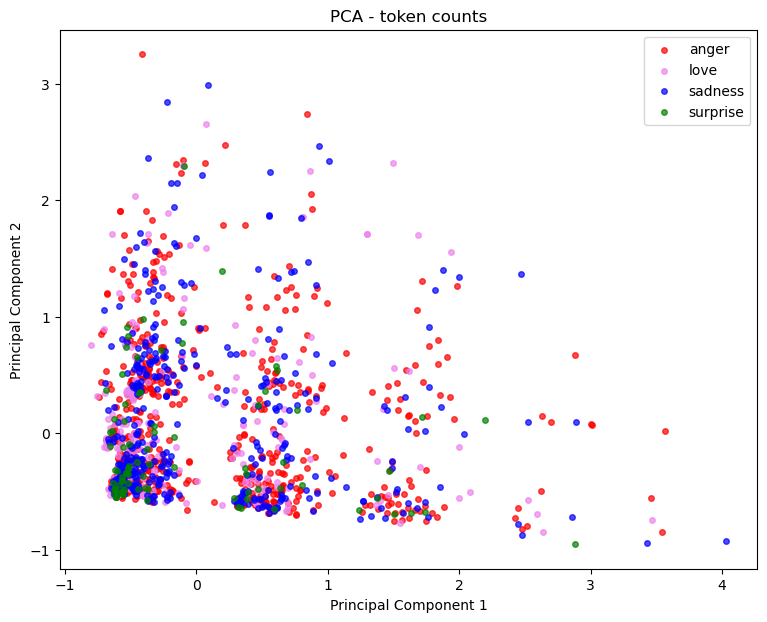

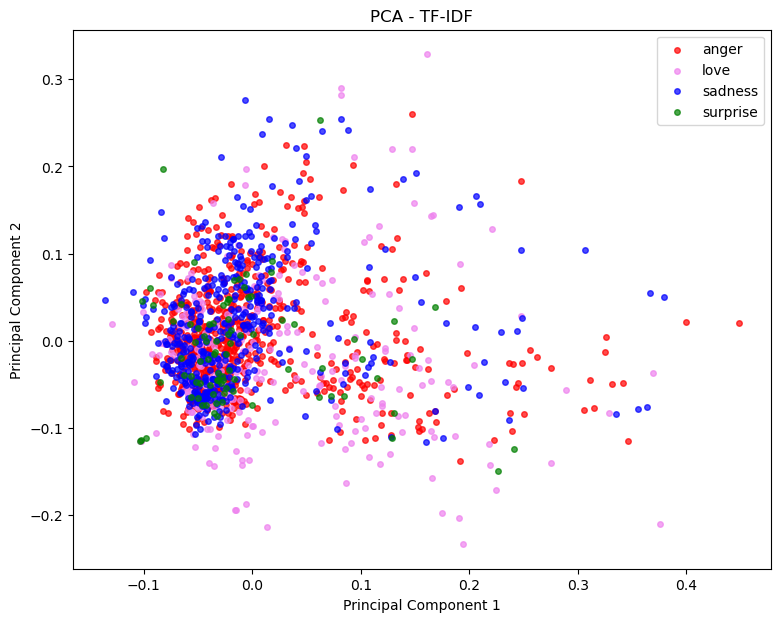

In [25]:
chosen_emotions = ["anger", "love", "sadness", "surprise"] # I thought they would be differnet enough to be separable
print("Four classes:", ", ".join(chosen_emotions))

# Keeping the tweet only if exactly one of my four emotions is True.
keep = []
for i, row in enumerate(rows):
    count = 0
    for emotion in chosen_emotions:
        if row[emotion]:
            count = count + 1
    if count == 1:
        keep.append(i)

# For each kept tweet, storing the one chosen emotion that is True.
emo_labels = []
for i in keep:
    for emotion in chosen_emotions:
        if rows[i][emotion]:
            emo_labels.append(emotion)
            break   # only one tag, so we can stop
emo_labels = np.array(emo_labels)

#print(len(keep))

for emotion in chosen_emotions:
    n = (emo_labels == emotion).sum()   # how many kept tweets have this label
    print((emotion, n))

color_list = ["red", "violet", "blue", "green"]
emotion_colors = {}
for i, emotion in enumerate(chosen_emotions):
    emotion_colors[emotion] = color_list[i]

# Plot 1: token counts
count_kept = count_features[keep].toarray()
points_count = PCA(n_components=2).fit_transform(count_kept)
plot_2d(points_count, emo_labels, "PCA - token counts", emotion_colors)

# Plot 2: TF-IDF
tfidf_kept = tfidf_features[keep].toarray()
points_tfidf = PCA(n_components=2).fit_transform(tfidf_kept)
plot_2d(points_tfidf, emo_labels, "PCA - TF-IDF", emotion_colors)


#### Four classes chosen: anger, love, sadness, surprise.

#### Same as the previous plot, I am not seeing visually separable classes. In the first plot, I can see five regions, but they are all overlapping. In the second graph it seems there are four regions (one may say three as well), but they also have overlapping emotions.